<center><h1>IRIS_DATASET</h1></center>

- Simple classification problem.

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.datasets import load_iris
iris_dataset = load_iris()

In [98]:
print(iris_dataset.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [99]:
iris_dataset.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [100]:
iris_dataset.feature_names


['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [101]:
df = pd.DataFrame(data = iris_dataset.data, columns= iris_dataset.feature_names)
df["target"] = iris_dataset.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [102]:
iris_dataset.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [103]:
print(iris_dataset["DESCR"][:193])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 


In [104]:
df.shape

(150, 5)

In [105]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [106]:
df["target_names"] = df["target"].map(lambda x : "setosa" if x == 0 else "versicolor" if x == 1 else "virginica")

In [107]:

X = df.iloc[:,0:4]
y = df.iloc[:,-2]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size= 0.75, random_state= 0)

In [136]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.015440,-0.119255,0.225127,0.355798
1,-0.099845,-1.040395,0.113560,-0.029841
2,1.053005,-0.119255,0.950314,1.127075
3,-1.367980,0.341315,-1.392599,-1.315303
4,1.168290,0.111030,0.727180,1.384168
...,...,...,...,...
107,-1.137410,0.111030,-1.281032,-1.443850
108,0.476580,-0.349540,1.006098,0.741436
109,-0.099845,-0.810110,0.169343,-0.286934
110,2.090570,1.723026,1.619718,1.255621


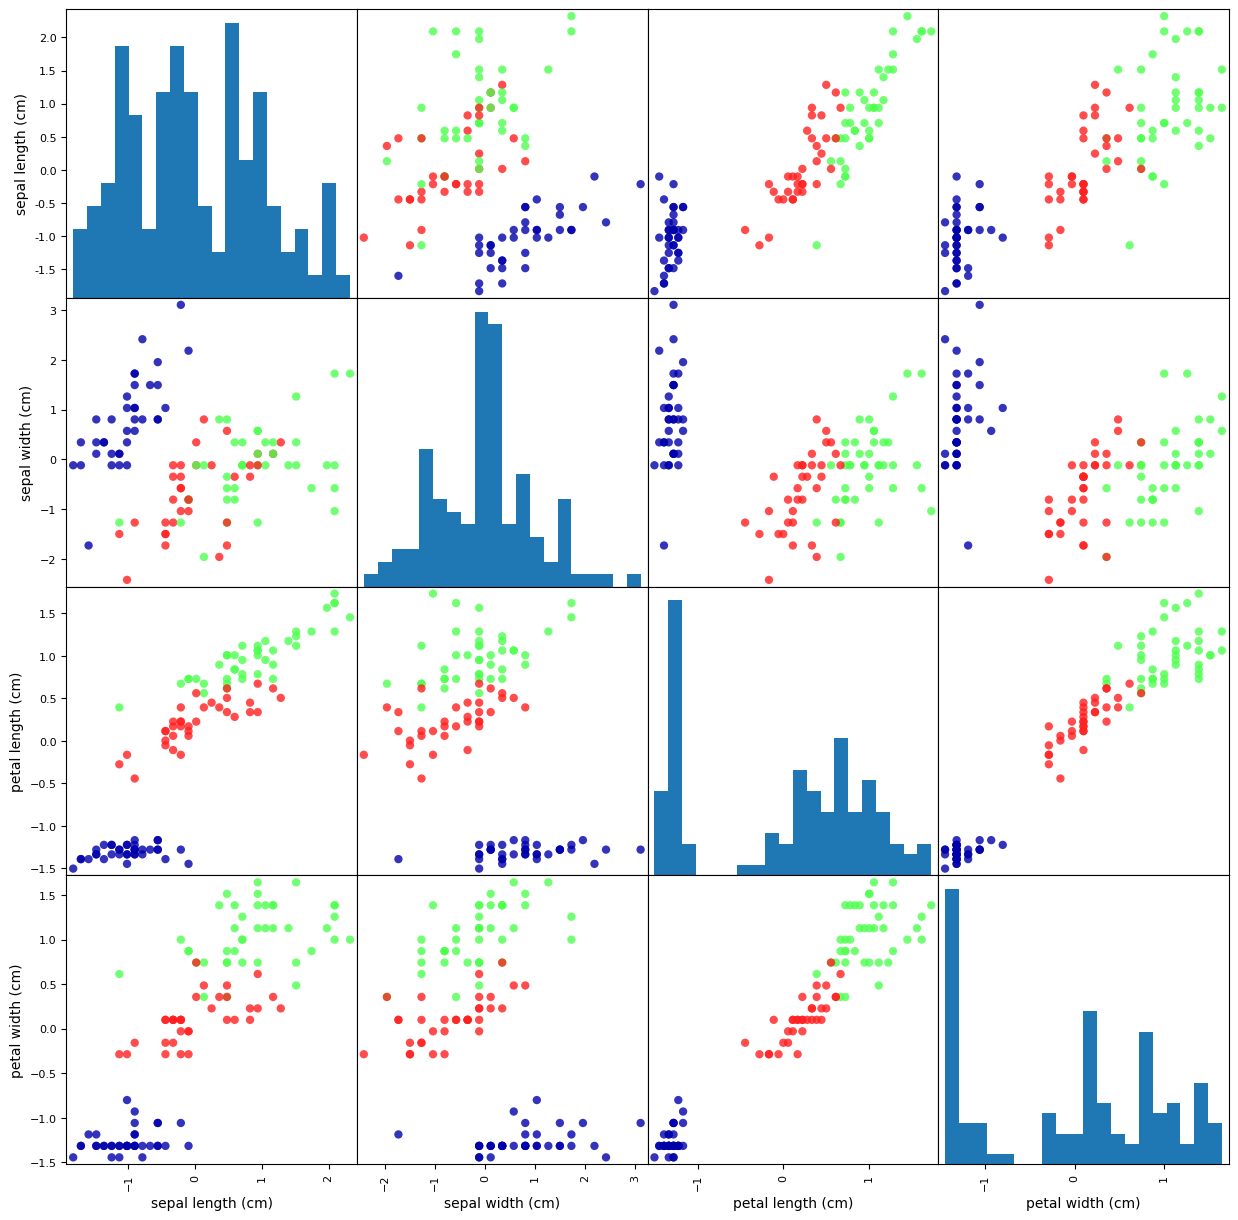

In [137]:
from pandas.plotting import scatter_matrix
grr = scatter_matrix(X_train, c = y_train, figsize = (15,15), marker = "-", hist_kwds = {"bins" : 20}, alpha = 0.8, cmap = mglearn.cm3)

In [138]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [139]:
#prediction for a singular case

X_new = np.array([[5,2.9,1,0.2]])
prediction = knn.predict(X_new)
print(f"Prediction : {prediction}")
print(f"Predicted target name: {iris_dataset["target_names"][prediction]}")

Prediction : [2]
Predicted target name: ['virginica']


c:\Users\vineet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [140]:
y_pred = knn.predict(X_test)
print(f"Test set prediction: {y_pred}")

Test set prediction: [2 1 0 2 0 2 0 1 2 1 2 1 1 1 1 0 2 1 0 0 2 2 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [141]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  0,  0],
       [ 0, 12,  4],
       [ 0,  0,  9]])

In [142]:
ac = accuracy_score(y_test, y_pred)
ac

0.8947368421052632

### The classification model is 97% accurate

## PCA

In [159]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = pd.DataFrame(sc.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(sc.fit_transform(X_test), columns = X_test.columns)

In [ ]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.015440,-0.119255,0.225127,0.355798
1,-0.099845,-1.040395,0.113560,-0.029841
2,1.053005,-0.119255,0.950314,1.127075
3,-1.367980,0.341315,-1.392599,-1.315303
4,1.168290,0.111030,0.727180,1.384168
...,...,...,...,...
107,-1.137410,0.111030,-1.281032,-1.443850
108,0.476580,-0.349540,1.006098,0.741436
109,-0.099845,-0.810110,0.169343,-0.286934
110,2.090570,1.723026,1.619718,1.255621


In [ ]:
np.mean(X_train)

np.float64(2.0221919377101065e-16)

In [ ]:
np.std(X_train, axis = 0)

sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64

In [ ]:
from sklearn.decomposition import PCA
pc = PCA(n_components = 2)
pc_Xtrain = pd.DataFrame(pc.fit_transform(X_train), columns = ["pc_1", "pc_2"])

In [ ]:
pc_Xtrain

,pc_1,pc_2
0,0.368830,-0.090875
1,0.221418,-1.014508
2,1.787405,0.289367
3,-2.369744,-0.194419
4,1.815543,0.554869
...,...,...
107,-2.204870,-0.340228
108,1.341684,-0.135169
109,0.057286,-0.808413
110,2.407103,2.377823


In [ ]:
print('Explained variability per principal component: {}'.format(pc.explained_variance_ratio_))

Explained variability per principal component: [0.72216128 0.24132364]


In [ ]:
pc_Xtest = pd.DataFrame(pc.fit_transform(X_test), columns = ["pc_1", "pc_2"])
pc_Xtest

,pc_1,pc_2
0,1.788845,-0.248906
1,1.044248,-1.449060
2,-2.687776,1.791683
3,2.715338,1.126751
4,-2.261589,-0.144218
5,2.060725,1.159599
6,-2.346439,0.052703
7,1.323825,0.930556
8,1.633798,0.427321
9,0.783919,-0.180302


In [161]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(pc_Xtrain, y_train)

KNeighborsClassifier()

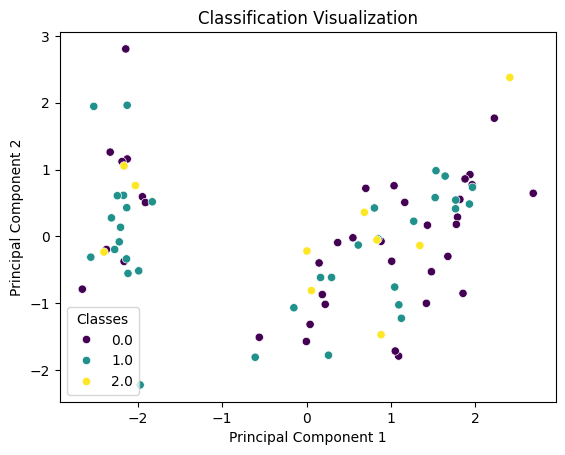

In [172]:
sns.scatterplot(data=pc_Xtrain, x="pc_1", y="pc_2", hue=y_train, palette="viridis")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Classification Visualization")
plt.legend(title="Classes")
plt.show()

In [173]:
y_pred = knn.predict(pc_Xtest)

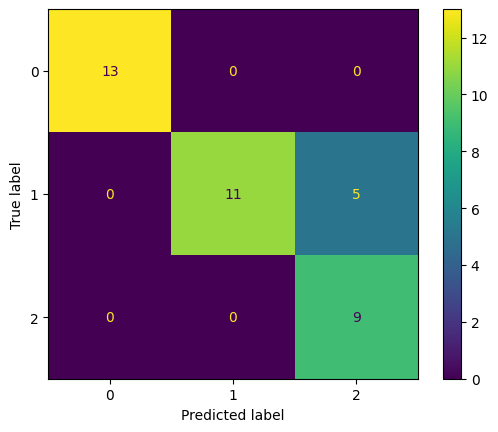

In [176]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot()
plt.show()

In [178]:
ac = accuracy_score(y_test, y_pred)
ac

0.868421052631579

Earlier Accuracy was **0.8947368421052632** but now it is **0.868421052631579**, not much trade-off for reduction of two features.